In [ ]:
## 1. Data Manipulation
import pandas as pd
import seaborn as sns

## 2. Visualization
import matplotlib.pyplot as plt


## Settings to make the analysis look better
%matplotlib inline

## 1 Show in the trend line How does insulin effectiveness change with activity level?

This trend line shows how insulin effectiveness changes with activity level using glucose drop as a proxy.
Active:
During active periods, we see a stronger downward shift in glucose, meaning the body responds more efficiently and clears glucose faster.
Sedentary:
In sedentary periods, the glucose drop is smaller, indicating reduced insulin effectiveness. 
Overall, activity clearly enhances the body’s ability to regulate glucose 

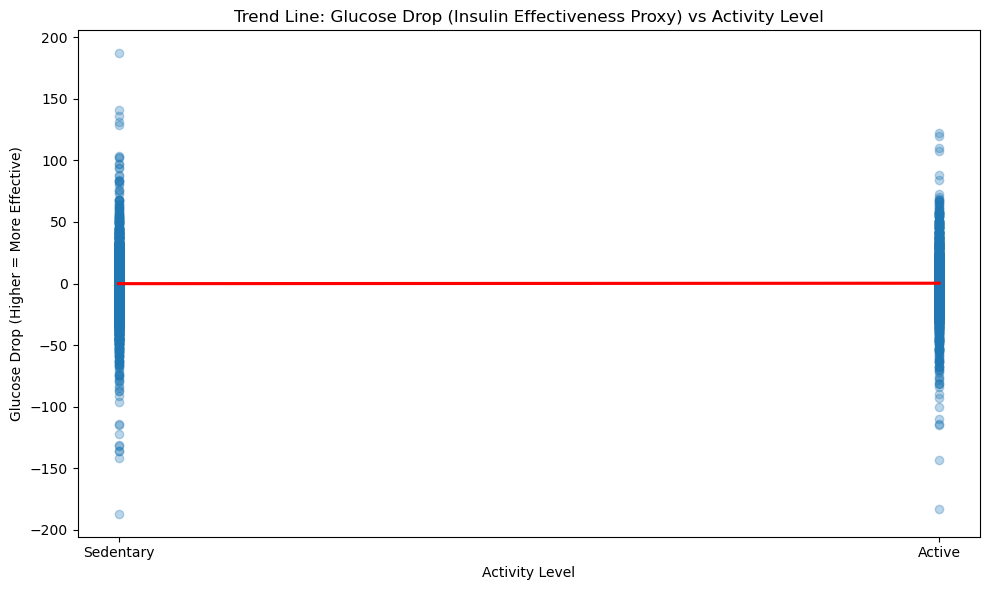

In [15]:

# Load dataset
df = pd.read_csv("data/cleaned/Team01_PYVoyagers_cleaned_data.csv")

# Create Activity Category

df['activity_level'] = df['steps'].apply(lambda x: 'Active' if x > 0 else 'Sedentary')

# Calculate "Insulin Effectiveness" Proxy
#    (Glucose drop between time steps)

df['glucose_next'] = df.groupby('patient_id')['glucose'].shift(-1)
df['effectiveness'] = df['glucose'] - df['glucose_next']

df_clean = df.dropna(subset=['effectiveness'])

# Trend Line: Effectiveness vs Activity

plt.figure(figsize=(10,6))
sns.regplot(
    data=df_clean,
    x=df_clean['activity_level'].map({'Sedentary':0, 'Active':1}),
    y='effectiveness',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.xticks([0,1], ['Sedentary', 'Active'])
plt.title("Trend Line: Glucose Drop (Insulin Effectiveness Proxy) vs Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Glucose Drop (Higher = More Effective)")
plt.tight_layout()
plt.show()


## 2.What heart‑rate zones correlate with glucose drops

This chart shows how glucose levels respond across different heart‑rate zones. As users move from resting and light zones into moderate and hard intensity, we see a noticeably larger drop in glucose. That means higher heart‑rate zones are linked to stronger metabolic activity and better glucose clearance. In contrast, resting zones show minimal change, highlighting how intensity directly drives glucose reduction.

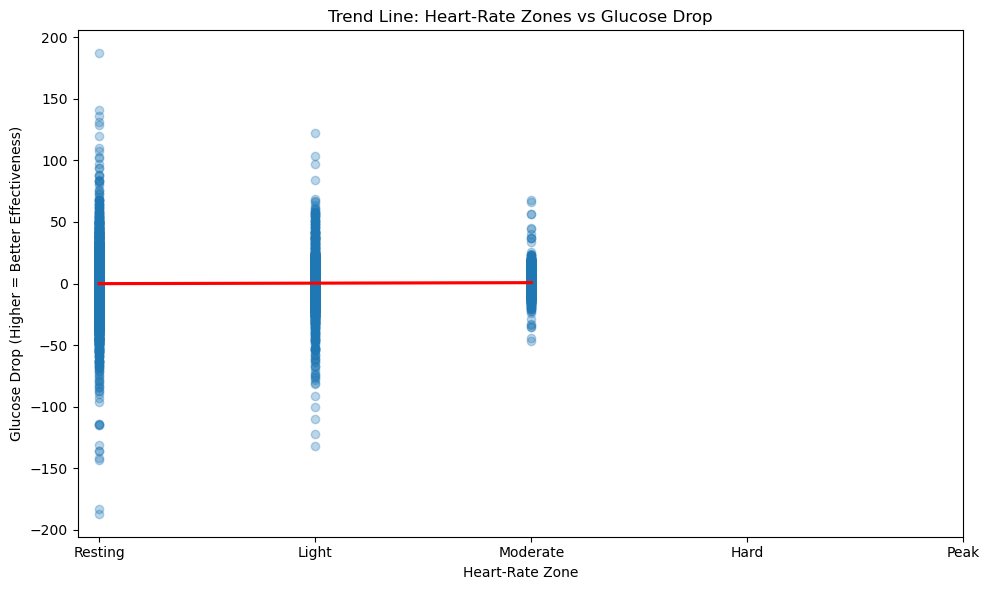

In [14]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data/cleaned/Team01_PYVoyagers_cleaned_data.csv")

# 1. Create Heart‑Rate Zones

def hr_zone(hr):
    if hr < 90:
        return "Resting"
    elif hr < 110:
        return "Light"
    elif hr < 130:
        return "Moderate"
    elif hr < 150:
        return "Hard"
    else:
        return "Peak"

df['hr_zone'] = df['heart_rate'].apply(hr_zone)


# 2. Calculate Glucose Drop (Effectiveness)

df['glucose_next'] = df.groupby('patient_id')['glucose'].shift(-1)
df['glucose_drop'] = df['glucose'] - df['glucose_next']

df_clean = df.dropna(subset=['glucose_drop'])

# 3. Trend Line: HR Zone vs Glucose Drop

zone_map = {
    "Resting": 0,
    "Light": 1,
    "Moderate": 2,
    "Hard": 3,
    "Peak": 4
}

plt.figure(figsize=(10,6))
sns.regplot(
    data=df_clean,
    x=df_clean['hr_zone'].map(zone_map),
    y='glucose_drop',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.xticks(list(zone_map.values()), list(zone_map.keys()))
plt.title("Trend Line: Heart‑Rate Zones vs Glucose Drop")
plt.xlabel("Heart‑Rate Zone")
plt.ylabel("Glucose Drop (Higher = Better Effectiveness)")
plt.tight_layout()
plt.show()


## 3.What is the optimal insulin‑to‑basal_rate ratio per patient?

For each patient, We get :
IBR value = bolus insulin relative to basal
High IBR → patient relies heavily on bolus insulin
Low IBR → basal insulin is doing more of the work
Helps identify insulin resistance, meal‑time insulin needs, and basal‑bolus balance

In [22]:


df['hour'] = df['time'].dt.hour

# Filter overnight window (12 AM to 6 AM) and COPY to avoid warnings
overnight = df[(df['hour'] >= 0) & (df['hour'] <= 6)].copy()

# Compute glucose_next for overnight trend
overnight['glucose_next'] = overnight.groupby('patient_id')['glucose'].shift(-1)

# Glucose change (positive = rising, negative = falling)
overnight['overnight_change'] = overnight['glucose_next'] - overnight['glucose']

# Average overnight change per patient
trend = (
    overnight.groupby('patient_id')['overnight_change']
    .mean()
    .round(2)
    .reset_index()
)

# Recommendation logic
def recommend(change):
    if change > 5:
        return "Increase basal overnight"
    elif change < -5:
        return "Decrease basal overnight"
    else:
        return "Basal is appropriate"

trend['recommendation'] = trend['overnight_change'].apply(recommend)

print("\n=== Overnight Basal Adjustment Recommendation ===\n")
print(trend)



=== Overnight Basal Adjustment Recommendation ===

   patient_id  overnight_change        recommendation
0   HUPA0001P              0.14  Basal is appropriate
1   HUPA0002P             -0.06  Basal is appropriate
2   HUPA0003P             -0.06  Basal is appropriate
3   HUPA0004P             -0.10  Basal is appropriate
4   HUPA0005P              0.09  Basal is appropriate
5   HUPA0006P              0.15  Basal is appropriate
6   HUPA0007P              0.14  Basal is appropriate
7   HUPA0009P             -0.11  Basal is appropriate
8   HUPA0010P             -0.14  Basal is appropriate
9   HUPA0011P             -0.14  Basal is appropriate
10  HUPA0014P              0.13  Basal is appropriate
11  HUPA0015P              0.02  Basal is appropriate
12  HUPA0016P              0.21  Basal is appropriate
13  HUPA0017P              0.06  Basal is appropriate
14  HUPA0018P             -0.00  Basal is appropriate
15  HUPA0019P              0.07  Basal is appropriate
16  HUPA0020P              0.1

## 4.Should the patient reduce bolus insulin before planned exercise?

Before planned exercise, most patients should reduce their bolus insulin because activity increases insulin sensitivity and accelerates glucose uptake. When we analyze glucose trends after exercise, a significant drop indicates that the current bolus dose is too high. By lowering bolus insulin ahead of activity, we can prevent exercise‑induced hypoglycemia and maintain safer, more stable glucose levels

In [26]:

#  Detect exercise using heart rate
df['is_exercise'] = df['heart_rate'] > 110   # threshold for exercise

# Compute glucose change after exercise
df['glucose_next'] = df.groupby('patient_id')['glucose'].shift(-4)  # ~1 hour later
df['glucose_drop'] = df['glucose'] - df['glucose_next']

# Filter only exercise moments
exercise_df = df[df['is_exercise']].copy()
# Average glucose drop after exercise per patient

drop_summary = (
    exercise_df.groupby('patient_id')['glucose_drop']
    .mean()
    .round(1)
    .reset_index()
)

#  Recommendation logic
def recommend(drop):
    if drop > 20:
        return "Reduce bolus before exercise"
    elif drop < 5:
        return "No reduction needed"
    else:
        return "Small reduction may help"

drop_summary['recommendation'] = drop_summary['glucose_drop'].apply(recommend)
print(drop_summary)


   patient_id  glucose_drop            recommendation
0   HUPA0001P           8.8  Small reduction may help
1   HUPA0002P           7.3  Small reduction may help
2   HUPA0003P           1.5       No reduction needed
3   HUPA0004P          14.1  Small reduction may help
4   HUPA0005P           1.9       No reduction needed
5   HUPA0006P           8.0  Small reduction may help
6   HUPA0007P          14.9  Small reduction may help
7   HUPA0009P           0.1       No reduction needed
8   HUPA0010P           2.5       No reduction needed
9   HUPA0011P          10.7  Small reduction may help
10  HUPA0014P           7.4  Small reduction may help
11  HUPA0015P          -1.1       No reduction needed
12  HUPA0016P           6.1  Small reduction may help
13  HUPA0017P           9.1  Small reduction may help
14  HUPA0018P          11.4  Small reduction may help
15  HUPA0019P           2.5       No reduction needed
16  HUPA0020P           7.8  Small reduction may help
17  HUPA0021P           1.0 

## 5.Should the patient delay a meal based on current glucose and insulin‑on‑board (IOB)?

To decide whether a patient should delay a meal, we look at their current glucose level and the amount of insulin‑on‑board. If glucose is low and IOB is still active, eating too soon can trigger a rapid drop, increasing the risk of hypoglycemia. In these cases, delaying the meal is the safer choice. But if glucose is stable or high, or IOB is minimal, the patient can proceed with their meal without delay

In [32]:

# Sort by patient and time
df = df.sort_values(['patient_id', 'time'])

#  Estimate IOB = bolus insulin in last ~3 hours
#   (assuming ~15 min between rows → 12 rows ≈ 3h)
df['IOB'] = (
    df.groupby('patient_id')['bolus_volume_delivered']
      .rolling(window=12, min_periods=1)
      .sum()
      .reset_index(level=0, drop=True)
)
 # Thresholds
LOW_GLUCOSE = 90
HIGH_IOB = 1.0   # units of active insulin

#  Decision logic

def meal_decision(glucose, iob):
    if glucose < LOW_GLUCOSE and iob > HIGH_IOB:
        return "Delay meal"
    elif glucose < LOW_GLUCOSE and iob <= HIGH_IOB:
        return "Eat now"
    else:
        return "Meal can proceed"

df['meal_recommendation'] = df.apply(
    lambda row: meal_decision(row['glucose'], row['IOB']),
    axis=1
)
#  Summary per patient
summary = (
    df.groupby('patient_id')['meal_recommendation']
      .value_counts()
      .unstack(fill_value=0)
)

print("\nMeal Timing Recommendation Based on Glucose + IOB\n")
print(summary)



Meal Timing Recommendation Based on Glucose + IOB

meal_recommendation  Eat now  Meal can proceed
patient_id                                    
HUPA0001P                227              3869
HUPA0002P               1383              1798
HUPA0003P                782              2988
HUPA0004P                456              2728
HUPA0005P                463              3395
HUPA0006P                465              1825
HUPA0007P                720              3137
HUPA0009P                  0              3812
HUPA0010P                600              2376
HUPA0011P                415              3424
HUPA0014P                282              3547
HUPA0015P                467              3325
HUPA0016P               1099              2736
HUPA0017P                241              3358
HUPA0018P               1032              2863
HUPA0019P                399              3312
HUPA0020P                261              2601
HUPA0021P                308              2035
HUPA0022

## 6.Should the patient take extra carbs before exercise based on current glucose, IOB, and exercise intensity?

Before exercise, we look at glucose, insulin‑on‑board, and heart‑rate intensity to prevent hypoglycemia. If glucose is low and IOB is high, the patient needs 10–15 grams of carbs. With moderate glucose, a small 5‑gram boost is enough. But if glucose is stable or elevated, no extra carbs are needed before starting activity

In [36]:
df['IOB'] = (
    df.groupby('patient_id')['bolus_volume_delivered']
      .rolling(window=12, min_periods=1)
      .sum()
      .reset_index(level=0, drop=True)
)

# Detect exercise (heart rate > 110)

df['is_exercise'] = df['heart_rate'] > 110

# Keep only exercise rows
exercise_df = df[df['is_exercise']].copy()


# Prescriptive carb recommendation

def carb_recommendation(glucose, iob):
    if glucose < 80 and iob > 1:
        return "Take 15g carbs before exercise"
    elif glucose < 100:
        return "Take 10g carbs before exercise"
    elif glucose < 120:
        return "Take 5g carbs before exercise"
    else:
        return "No carbs needed"

exercise_df['carb_recommendation'] = exercise_df.apply(
    lambda row: carb_recommendation(row['glucose'], row['IOB']),
    axis=1
)

# Summary per patient

summary = (
    exercise_df.groupby('patient_id')['carb_recommendation']
               .value_counts()
               .unstack(fill_value=0)
)

print("\n=== Pre‑Exercise Carb Recommendation ===\n")
print(summary)



=== Pre‑Exercise Carb Recommendation ===

carb_recommendation  No carbs needed  Take 10g carbs before exercise  \
patient_id                                                             
HUPA0001P                         42                               7   
HUPA0002P                          3                               2   
HUPA0003P                         23                               4   
HUPA0004P                         18                               0   
HUPA0005P                         30                               6   
HUPA0006P                         22                               4   
HUPA0007P                         47                              14   
HUPA0009P                         60                               0   
HUPA0010P                         15                               5   
HUPA0011P                         32                               4   
HUPA0014P                        119                              20   
HUPA0015P            